# Human Survey Analysis

## Methodology Notes

In [11]:
import csv
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 200)


In [12]:
TASK_CSV = Path('./human_study_task_results_template.csv')
INTERVIEW_CSV = Path('./human_study_participants_interview_template.csv')
MANIFEST_JSON = Path('./generated_surveys/survey_manifest.json')

TASK_CSV, INTERVIEW_CSV, MANIFEST_JSON


(PosixPath('human_study_task_results_template.csv'),
 PosixPath('human_study_participants_interview_template.csv'),
 PosixPath('generated_surveys/survey_manifest.json'))

In [13]:
def read_csv_trimmed(path: Path) -> pd.DataFrame:
    """Read a CSV whose data rows may have trailing empty cells beyond the header width."""
    with path.open(newline='', encoding='utf-8-sig') as f:
        rows = list(csv.reader(f))
    header = [str(col).replace('\ufeff', '').strip() for col in rows[0]]
    cleaned_rows = []
    for row in rows[1:]:
        if not any(cell.strip() for cell in row):
            continue
        if len(row) < len(header):
            row = row + [''] * (len(header) - len(row))
        elif len(row) > len(header):
            row = row[:len(header)]
        cleaned_rows.append(row)
    return pd.DataFrame(cleaned_rows, columns=header).replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})


def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=42):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    means = samples.mean(axis=1)
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return float(lo), float(hi)


def plot_grouped_points(summary_df, metric, title, ylabel, ylim=None):
    datasets = list(summary_df['dataset'].dropna().unique())
    conditions = ['prototypes_only', 'prototypes_plus_rules']
    colors = {'prototypes_only': '#4C78A8', 'prototypes_plus_rules': '#F58518'}
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 4), sharey=True)
    if len(datasets) == 1:
        axes = [axes]
    for ax, dataset in zip(axes, datasets):
        subset = summary_df[summary_df['dataset'] == dataset]
        for x, condition in enumerate(conditions):
            cond_df = subset[subset['condition'] == condition]
            y = cond_df[metric].dropna().to_numpy(dtype=float)
            if len(y) == 0:
                continue
            jitter = np.linspace(-0.08, 0.08, len(y)) if len(y) > 1 else np.array([0.0])
            ax.scatter(np.full(len(y), x) + jitter, y, color=colors[condition], alpha=0.8, s=45)
            mean = y.mean()
            lo, hi = bootstrap_ci(y)
            ax.errorbar(x, mean, yerr=[[mean - lo], [hi - mean]], fmt='o', color='black', capsize=4)
        ax.set_title(dataset)
        ax.set_xticks(range(len(conditions)))
        ax.set_xticklabels(['Prototypes only', 'Prototypes + rules'], rotation=12)
        ax.set_xlabel('Condition')
        ax.grid(axis='y', alpha=0.3)
    axes[0].set_ylabel(ylabel)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


def likert_barplot(long_df, title):
    item_order = [
        'understood_classes',
        'information_sufficient',
        'easy_to_apply',
        'matched_visible_patterns',
        'confident',
        'too_vague_rev',
        'too_much_detail_rev',
    ]
    label_map = {
        'understood_classes': 'Understood classes',
        'information_sufficient': 'Information sufficient',
        'easy_to_apply': 'Easy to apply',
        'matched_visible_patterns': 'Matched visible patterns',
        'confident': 'Felt confident',
        'too_vague_rev': 'Not too vague',
        'too_much_detail_rev': 'Not too much detail',
    }
    conditions = ['prototypes_only', 'prototypes_plus_rules']
    colors = {'prototypes_only': '#4C78A8', 'prototypes_plus_rules': '#F58518'}
    means = (long_df.groupby(['item', 'condition'])['value']
                  .mean()
                  .reindex(pd.MultiIndex.from_product([item_order, conditions], names=['item', 'condition']))
                  .reset_index())
    x = np.arange(len(item_order))
    width = 0.36
    fig, ax = plt.subplots(figsize=(12, 5))
    for offset, condition in [(-width / 2, conditions[0]), (width / 2, conditions[1])]:
        vals = means[means['condition'] == condition]['value'].to_numpy(dtype=float)
        ax.bar(x + offset, vals, width=width, color=colors[condition], label=condition.replace('_', ' '), alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([label_map[i] for i in item_order], rotation=20, ha='right')
    ax.set_ylim(1, 5)
    ax.set_ylabel('Mean Likert rating (1-5)')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    return fig


In [14]:
task_raw = read_csv_trimmed(TASK_CSV)
interview_raw = read_csv_trimmed(INTERVIEW_CSV)
manifest = json.loads(MANIFEST_JSON.read_text())

print('Task rows:', len(task_raw))
print('Interview rows:', len(interview_raw))
print('Manifest participants:', len(manifest))
display(task_raw.head())
display(interview_raw.head())


Task rows: 40
Interview rows: 20
Manifest participants: 8


,participant_id,group,task_number,dataset,condition,inst1_pred,inst2_pred,inst3_pred,inst4_pred,inst5_pred,inst6_pred,inst7_pred,inst8_pred,inst9_pred,inst10_pred,inst1_confidence,inst2_confidence,inst3_confidence,inst4_confidence,inst5_confidence,inst6_confidence,inst7_confidence,inst8_confidence,inst9_confidence,inst10_confidence,rating_understood_classes,rating_information_sufficient,rating_easy_to_apply,rating_matched_visible_patterns,rating_confident,rating_too_vague,rating_too_much_detail,task_note
0,P01,A,1,Chinatown,prototypes_only,2,2,2,2,2,1,2,1,1,1,4,3,1,5,5,1,5,1,5,4,4,2,2,4,4,4,1,<NA>
1,P01,A,2,ECG200,prototypes_rules,2,1,1,2,2,1,1,1,1,1,5,5,5,5,5,4,4,4,4,4,5,4,4,4,4,1,1,<NA>
2,P02,A,1,Chinatown,prototypes_only,2,1,1,2,2,2,2,1,1,2,4,3,4,3,3,4,3,4,4,3,3,2,2,3,3,4,2,"I can see some pattern, but the difference is not significant."
3,P02,A,2,ECG200,prototypes_rules,2,1,1,2,2,2,2,2,1,1,5,5,5,5,5,5,3,3,5,5,4,3,3,4,4,3,2,The explanation provided is better than the one from Task 1.
4,P03,A,1,Chinatown,prototypes_only,2,1,1,2,2,2,2,1,1,1,3,2,3,3,2,3,3,3,1,1,2,2,2,3,1,4,1,<NA>


,participant_id,group,ml_familiarity,ts_plot_familiarity,xai_rules_familiarity,1,2,3,4,5,6
0,P01,A,2,3,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,P02,A,3,2,1,The trend of the curve,"Yes, it helps a bit the rules about where the curves goes up and down.","I guess the rules are made to avoid overfitting. So there are phrases such as 'ofren', 'tends' in the rules. But this may lead to confusion. Because there are sometimes both read and blue contained.",rules,both,It helps me to understand the classifier better.
2,P03,A,2,5,1,"In task 1 I mainly used the slope at the very start, in task 2 steepness of recovery and have gradual transition","I mainly focused on the slope, slow vs fast recovery",Any rule not quantified will have instances on the boarder e.g where is the cut off point between fast and clear.,I relied mainly on the examples. but rules told me where to focus,both,rules made me understand the classification better.
3,P04,A,4,2,4,"Task 1, even bumps, taks 3 drastic upwards steps declining/upwards at the end.","Yes, late region declines/goes up",No,Rules,Both,"Yes, helped me understand the classifier better"
4,P05,A,4,4,3,"Abrupt changes, steepness and jaggedness","The rules were crucial, part two felt way easier","As mentioned, one example could have been representative of the other class. Other than that, I felt confident in my ability to classify each class in part 2",Mostly rules,"Both preferably, but rules would be sufficient",I could see how rules could improve my ability to classify


## Build Answer Key


In [15]:
answer_key_by_dataset = {}
instance_ids_by_dataset = {}
manifest_task_lookup = {}

for participant in manifest:
    group = participant['group']
    subject_code = participant['subject_code']
    for task in participant['tasks']:
        dataset = task['dataset']
        task_number = int(task['task_number'])
        labels = [int(x['classifier_label']) for x in task['test_instances']]
        ts_ids = [int(x['ts_idx']) for x in task['test_instances']]
        if dataset in answer_key_by_dataset:
            assert answer_key_by_dataset[dataset] == labels
            assert instance_ids_by_dataset[dataset] == ts_ids
        else:
            answer_key_by_dataset[dataset] = labels
            instance_ids_by_dataset[dataset] = ts_ids
        manifest_task_lookup[(group, task_number)] = {
            'subject_code': subject_code,
            'dataset': dataset,
            'condition': task['condition'],
            'best_promptv3_accuracy': task['best_promptv3_accuracy'],
            'best_promptv3_repetition': task['best_promptv3_repetition'],
        }

pd.DataFrame([
    {
        'dataset': dataset,
        'instance_ids': instance_ids_by_dataset[dataset],
        'classifier_labels': answer_key_by_dataset[dataset],
    }
    for dataset in sorted(answer_key_by_dataset)
])


,dataset,instance_ids,classifier_labels
0,Chinatown,"[126, 114, 44, 71, 238, 196, 28, 203, 141, 79]","[1, 0, 0, 1, 1, 1, 1, 0, 0, 0]"
1,ECG200,"[43, 69, 22, 54, 16, 32, 25, 28, 15, 37]","[1, 0, 0, 1, 1, 1, 1, 0, 0, 0]"


In [16]:
task_df = task_raw.copy()
task_df.columns = [str(c).replace('\ufeff', '').strip() for c in task_df.columns]
task_df['group'] = task_df['group'].str.strip()
task_df['dataset'] = task_df['dataset'].str.strip()
task_df['condition'] = task_df['condition'].str.strip().replace({'prototypes_rules': 'prototypes_plus_rules'})
task_df['participant_id'] = task_df['participant_id'].str.strip()

prediction_cols = [f'inst{i}_pred' for i in range(1, 11)]
confidence_cols = [f'inst{i}_confidence' for i in range(1, 11)]
rating_cols = [
    'rating_understood_classes',
    'rating_information_sufficient',
    'rating_easy_to_apply',
    'rating_matched_visible_patterns',
    'rating_confident',
    'rating_too_vague',
    'rating_too_much_detail',
]

numeric_cols = ['task_number'] + prediction_cols + confidence_cols + rating_cols
for col in numeric_cols:
    task_df[col] = pd.to_numeric(task_df[col], errors='coerce')

pred_unique = sorted(pd.unique(task_df[prediction_cols].to_numpy().ravel()))
pred_unique = [x for x in pred_unique if not pd.isna(x)]
if set(pred_unique).issubset({1.0, 2.0}):
    prediction_offset = 1
elif set(pred_unique).issubset({0.0, 1.0}):
    prediction_offset = 0
else:
    raise ValueError(f'Unexpected prediction labels: {pred_unique}')

validation_df = pd.DataFrame({
    'unique_prediction_values': [pred_unique],
    'prediction_offset_applied': [prediction_offset],
    'datasets_in_task_csv': [sorted(task_df['dataset'].dropna().unique())],
    'conditions_in_task_csv': [sorted(task_df['condition'].dropna().unique())],
})
validation_df


,unique_prediction_values,prediction_offset_applied,datasets_in_task_csv,conditions_in_task_csv
0,"[1.0, 2.0]",1,"[Chinatown, ECG200]","[prototypes_only, prototypes_plus_rules]"


## Item-Level Table

In [17]:
item_rows = []
for _, row in task_df.iterrows():
    dataset = row['dataset']
    answer_key = answer_key_by_dataset[dataset]
    instance_ids = instance_ids_by_dataset[dataset]
    for i in range(1, 11):
        pred_raw = row[f'inst{i}_pred']
        pred_label = (pred_raw - prediction_offset) if pd.notna(pred_raw) else np.nan
        true_label = answer_key[i - 1]
        instance_id = instance_ids[i - 1]
        confidence = row[f'inst{i}_confidence']
        correct = (pred_label == true_label) if pd.notna(pred_label) else np.nan
        item_rows.append({
            'participant_id': row['participant_id'],
            'group': row['group'],
            'task_number': int(row['task_number']),
            'dataset': dataset,
            'condition': row['condition'],
            'instance_number': i,
            'instance_id': instance_id,
            'true_label': int(true_label),
            'pred_raw': pred_raw,
            'pred_label': pred_label,
            'correct': float(correct) if pd.notna(correct) else np.nan,
            'confidence': confidence,
        })

item_df = pd.DataFrame(item_rows)
item_df['confidence_01'] = (item_df['confidence'] - 1) / 4
item_df['task_key'] = (
    item_df['participant_id'] + ' | T' + item_df['task_number'].astype(str) +
    ' | ' + item_df['dataset'] + ' | ' + item_df['condition']
)

print('Item rows:', len(item_df))
print('Missing predictions:', int(item_df['pred_label'].isna().sum()))
print('Missing confidences:', int(item_df['confidence'].isna().sum()))
display(item_df.head(12))


Item rows: 400
Missing predictions: 4
Missing confidences: 6


,participant_id,group,task_number,dataset,condition,instance_number,instance_id,true_label,pred_raw,pred_label,correct,confidence,confidence_01,task_key
0,P01,A,1,Chinatown,prototypes_only,1,126,1,2.0,1.0,1.0,4.0,0.75,P01 | T1 | Chinatown | prototypes_only
1,P01,A,1,Chinatown,prototypes_only,2,114,0,2.0,1.0,0.0,3.0,0.50,P01 | T1 | Chinatown | prototypes_only
2,P01,A,1,Chinatown,prototypes_only,3,44,0,2.0,1.0,0.0,1.0,0.00,P01 | T1 | Chinatown | prototypes_only
3,P01,A,1,Chinatown,prototypes_only,4,71,1,2.0,1.0,1.0,5.0,1.00,P01 | T1 | Chinatown | prototypes_only
4,P01,A,1,Chinatown,prototypes_only,5,238,1,2.0,1.0,1.0,5.0,1.00,P01 | T1 | Chinatown | prototypes_only
5,P01,A,1,Chinatown,prototypes_only,6,196,1,1.0,0.0,0.0,1.0,0.00,P01 | T1 | Chinatown | prototypes_only
6,P01,A,1,Chinatown,prototypes_only,7,28,1,2.0,1.0,1.0,5.0,1.00,P01 | T1 | Chinatown | prototypes_only
7,P01,A,1,Chinatown,prototypes_only,8,203,0,1.0,0.0,1.0,1.0,0.00,P01 | T1 | Chinatown | prototypes_only
8,P01,A,1,Chinatown,prototypes_only,9,141,0,1.0,0.0,1.0,5.0,1.00,P01 | T1 | Chinatown | prototypes_only
9,P01,A,1,Chinatown,prototypes_only,10,79,0,1.0,0.0,1.0,4.0,0.75,P01 | T1 | Chinatown | prototypes_only


In [18]:
item_checks = pd.DataFrame({
    'rows_expected': [len(task_df) * 10],
    'rows_observed': [len(item_df)],
    'participants': [task_df['participant_id'].nunique()],
    'datasets': [sorted(item_df['dataset'].unique())],
    'conditions': [sorted(item_df['condition'].unique())],
    'mean_accuracy_over_items': [item_df['correct'].mean()],
    'mean_confidence_over_items': [item_df['confidence'].mean()],
})
item_checks


,rows_expected,rows_observed,participants,datasets,conditions,mean_accuracy_over_items,mean_confidence_over_items
0,400,400,20,"[Chinatown, ECG200]","[prototypes_only, prototypes_plus_rules]",0.823232,3.42132


## Participant-Task Summary

In [19]:
task_metrics = []
for keys, subset in item_df.groupby(['participant_id', 'group', 'task_number', 'dataset', 'condition']):
    subset = subset.copy()
    conf_correct = subset.loc[subset['correct'] == 1, 'confidence']
    conf_incorrect = subset.loc[subset['correct'] == 0, 'confidence']
    task_metrics.append({
        'participant_id': keys[0],
        'group': keys[1],
        'task_number': keys[2],
        'dataset': keys[3],
        'condition': keys[4],
        'n_answered': subset['pred_label'].notna().sum(),
        'accuracy': subset['correct'].mean(),
        'mean_confidence': subset['confidence'].mean(),
        'mean_confidence_correct': conf_correct.mean(),
        'mean_confidence_incorrect': conf_incorrect.mean(),
        'high_confidence_rate': (subset['confidence'] >= 4).mean(),
    })

task_summary = pd.DataFrame(task_metrics)
task_summary['confidence_01'] = (task_summary['mean_confidence'] - 1) / 4
task_summary['calibration_gap'] = task_summary['confidence_01'] - task_summary['accuracy']

task_ratings = task_df[['participant_id', 'group', 'task_number', 'dataset', 'condition'] + rating_cols].copy()
task_ratings['too_vague_rev'] = 6 - task_ratings['rating_too_vague']
task_ratings['too_much_detail_rev'] = 6 - task_ratings['rating_too_much_detail']
task_ratings['explanation_quality_composite'] = task_ratings[[
    'rating_understood_classes',
    'rating_information_sufficient',
    'rating_easy_to_apply',
    'rating_matched_visible_patterns',
    'rating_confident',
    'too_vague_rev',
    'too_much_detail_rev',
]].mean(axis=1)

task_summary = task_summary.merge(
    task_ratings,
    on=['participant_id', 'group', 'task_number', 'dataset', 'condition'],
    how='left',
).sort_values(['participant_id', 'task_number']).reset_index(drop=True)

display(task_summary)


,participant_id,group,task_number,dataset,condition,n_answered,accuracy,mean_confidence,mean_confidence_correct,mean_confidence_incorrect,high_confidence_rate,confidence_01,calibration_gap,rating_understood_classes,rating_information_sufficient,rating_easy_to_apply,rating_matched_visible_patterns,rating_confident,rating_too_vague,rating_too_much_detail,too_vague_rev,too_much_detail_rev,explanation_quality_composite
0,P01,A,1,Chinatown,prototypes_only,10,0.700000,3.400000,4.142857,1.666667,0.6,0.600000,-1.000000e-01,4,2,2,4,4,4,1,2,5,3.285714
1,P01,A,2,ECG200,prototypes_plus_rules,10,0.800000,4.500000,4.625000,4.000000,1.0,0.875000,7.500000e-02,5,4,4,4,4,1,1,5,5,4.428571
2,P02,A,1,Chinatown,prototypes_only,10,0.900000,3.500000,3.555556,3.000000,0.5,0.625000,-2.750000e-01,3,2,2,3,3,4,2,2,4,2.714286
3,P02,A,2,ECG200,prototypes_plus_rules,10,0.900000,4.600000,4.777778,3.000000,0.8,0.900000,-1.110223e-16,4,3,3,4,4,3,2,3,4,3.571429
4,P03,A,1,Chinatown,prototypes_only,10,1.000000,2.400000,2.400000,NaN,0.0,0.350000,-6.500000e-01,2,2,2,3,1,4,1,2,5,2.428571
5,P03,A,2,ECG200,prototypes_plus_rules,10,0.800000,4.600000,4.875000,3.500000,0.9,0.900000,1.000000e-01,4,4,4,4,4,3,2,3,4,3.857143
6,P04,A,1,Chinatown,prototypes_only,10,0.600000,2.222222,2.666667,1.333333,0.0,0.305556,-2.944444e-01,2,4,4,4,1,4,2,2,4,3.000000
7,P04,A,2,ECG200,prototypes_plus_rules,8,0.625000,3.375000,3.400000,3.333333,0.5,0.593750,-3.125000e-02,4,4,4,4,3,2,2,4,4,3.857143
8,P05,A,1,Chinatown,prototypes_only,9,0.777778,3.333333,3.571429,2.500000,0.4,0.583333,-1.944444e-01,2,3,2,3,1,3,2,3,4,2.571429
9,P05,A,2,ECG200,prototypes_plus_rules,10,0.800000,4.600000,4.500000,5.000000,0.9,0.900000,1.000000e-01,5,5,5,4,5,2,1,4,5,4.714286


## Descriptive Tables

In [20]:
display(task_summary.groupby(['dataset', 'condition']).size().rename('n_tasks').reset_index())

display(
    task_summary.groupby(['dataset', 'condition'])[['accuracy', 'mean_confidence', 'explanation_quality_composite']]
                .agg(['mean', 'std', 'min', 'max'])
                .round(3)
)


,dataset,condition,n_tasks
0,Chinatown,prototypes_only,10
1,Chinatown,prototypes_plus_rules,10
2,ECG200,prototypes_only,10
3,ECG200,prototypes_plus_rules,10


accuracy                  mean_confidence  \
                                    mean    std  min  max            mean   
dataset   condition                                                         
Chinatown prototypes_only          0.798  0.142  0.6  1.0           3.126   
          prototypes_plus_rules    0.930  0.067  0.8  1.0           3.750   
ECG200    prototypes_only          0.770  0.116  0.5  0.9           2.679   
          prototypes_plus_rules    0.793  0.105  0.6  0.9           4.133   

                                                    \
                                   std    min  max   
dataset   condition                                  
Chinatown prototypes_only        0.536  2.222  3.7   
          prototypes_plus_rules  0.633  2.700  4.8   
ECG200    prototypes_only        1.322  1.000  4.0   
          prototypes_plus_rules  0.613  3.100  4.6   

                                explanation_quality_composite                \
                                                         mean    std    min   
dataset   condition                                                           
Chinatown prototypes_only                               2.929  0.388  2.429   
          prototypes_plus_rules                         3.886  0.446  3.143   
ECG200    prototypes_only                               2.571  0.828  1.571   
          prototypes_plus_rules                         3.514  0.797  2.143   

                                        
                                   max  
dataset   condition                     
Chinatown prototypes_only        3.429  
          prototypes_plus_rules  4.714  
ECG200    prototypes_only        4.143  
          prototypes_plus_rules  4.714

## Performance by Dataset and Condition

Because each participant sees both conditions but on different datasets, the cleanest descriptive comparison is:
- within each dataset: compare the participants who saw `prototypes_only` vs `prototypes_plus_rules`
- across task number: inspect whether task 2 tends to be easier because of learning/order


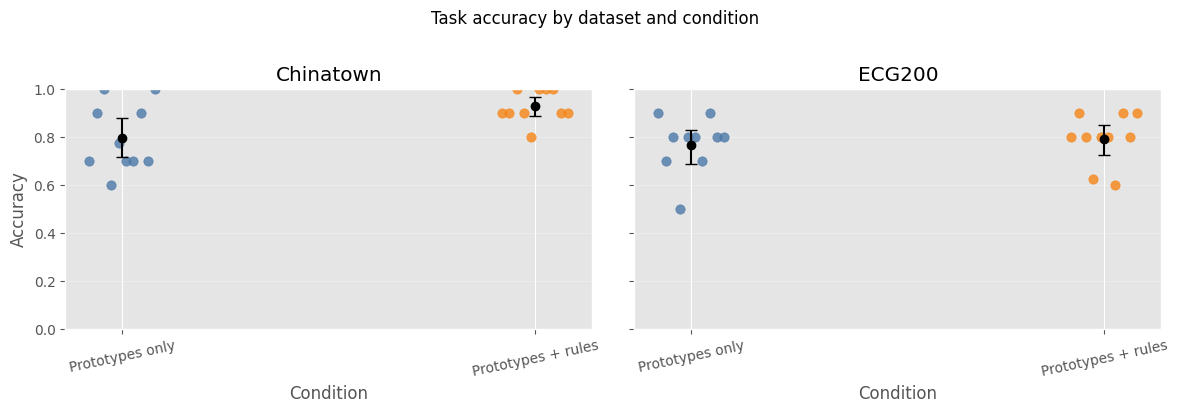

,mean,std,count
task_number,,,
1,0.824,0.112,20
2,0.821,0.138,20


In [21]:
plot_grouped_points(task_summary, 'accuracy', 'Task accuracy by dataset and condition', 'Accuracy', ylim=(0, 1))
plt.show()

task_summary.groupby('task_number')['accuracy'].agg(['mean', 'std', 'count']).round(3)


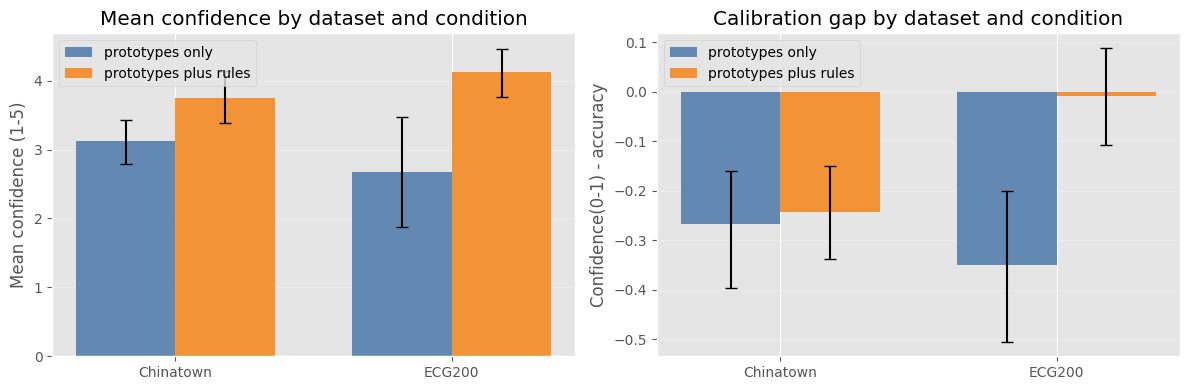

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title, ylabel in [
    (axes[0], 'mean_confidence', 'Mean confidence by dataset and condition', 'Mean confidence (1-5)'),
    (axes[1], 'calibration_gap', 'Calibration gap by dataset and condition', 'Confidence(0-1) - accuracy'),
]:
    datasets = list(task_summary['dataset'].dropna().unique())
    conditions = ['prototypes_only', 'prototypes_plus_rules']
    colors = {'prototypes_only': '#4C78A8', 'prototypes_plus_rules': '#F58518'}
    width = 0.36
    x = np.arange(len(datasets))
    for j, condition in enumerate(conditions):
        means = []
        cis = []
        for dataset in datasets:
            vals = task_summary[(task_summary['dataset'] == dataset) & (task_summary['condition'] == condition)][metric].dropna().to_numpy(dtype=float)
            means.append(vals.mean() if len(vals) else np.nan)
            cis.append(bootstrap_ci(vals) if len(vals) else (np.nan, np.nan))
        means = np.array(means, dtype=float)
        lo = np.array([m - ci[0] if not np.isnan(m) else np.nan for m, ci in zip(means, cis)], dtype=float)
        hi = np.array([ci[1] - m if not np.isnan(m) else np.nan for m, ci in zip(means, cis)], dtype=float)
        ax.bar(x + (j - 0.5) * width, means, width=width, color=colors[condition], alpha=0.85, label=condition.replace('_', ' '))
        ax.errorbar(x + (j - 0.5) * width, means, yerr=[lo, hi], fmt='none', color='black', capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()


## Proxy vs Human Summary Figure

This figure aligns the LLM proxy-evaluation results with the human-study outcomes.

- Panel A compares `prototypes only` vs `rules` in the proxy evaluation using the same result files used elsewhere in the repo.
- Panel B shows human task accuracy on the two datasets used in the survey.
- Panel C shows mean human confidence on the 1-5 scale.

Error bars are standard deviations across runs/participants within each condition.


In [23]:
proxy_specs = [
    ('Chinatown', 'Chinatown_baseline_3_2_llm_results.jsonl', 'Chinatown_rulebased_promptV3_3_0_llm_results.jsonl'),
    ('UMD', 'UMD_baseline_3_2_llm_results.jsonl', 'UMD_rulebased_promptV3_3_0_llm_results.jsonl'),
    ('ECG200', 'ECG200_baseline_3_2_llm_results.jsonl', 'ECG200_rulebased_promptV3_3_0_llm_results.jsonl'),
    ('Sony1', 'SonyAIBORobotSurface1_baseline_3_2_llm_results.jsonl', 'SonyAIBORobotSurface1_rulebased_promptV3_3_0_llm_results.jsonl'),
]

proxy_rows = []
for dataset_label, baseline_file, rules_file in proxy_specs:
    for condition_label, file_name in [('Prototypes only', baseline_file), ('Rules', rules_file)]:
        path = ROOT / 'results' / 'llm_results' / file_name
        with path.open() as f:
            for line in f:
                if not line.strip():
                    continue
                row = json.loads(line)
                proxy_rows.append({
                    'dataset': dataset_label,
                    'condition': condition_label,
                    'accuracy': float(row['accuracy']),
                })

proxy_df = pd.DataFrame(proxy_rows)
proxy_summary = (
    proxy_df.groupby(['dataset', 'condition'], as_index=False)
            .agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'))
)

human_summary_plot = (
    task_summary.groupby(['dataset', 'condition'], as_index=False)
                .agg(
                    mean_accuracy=('accuracy', 'mean'),
                    std_accuracy=('accuracy', 'std'),
                    mean_confidence=('mean_confidence', 'mean'),
                    std_confidence=('mean_confidence', 'std'),
                )
)

proxy_order = ['Chinatown', 'UMD', 'ECG200', 'Sony1']
human_order = ['Chinatown', 'ECG200']
condition_order = ['Prototypes only', 'Rules']
condition_color = {'Prototypes only': '#6B7C93', 'Rules': '#FF7A14'}
condition_map = {'prototypes_only': 'Prototypes only', 'prototypes_plus_rules': 'Rules'}

human_summary_plot['condition_label'] = human_summary_plot['condition'].map(condition_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={'width_ratios': [1.45, 1.0, 1.0]})
bar_width = 0.36

# Panel A: proxy accuracy
ax = axes[0]
x = np.arange(len(proxy_order))
for offset, condition in [(-bar_width / 2, 'Prototypes only'), (bar_width / 2, 'Rules')]:
    subset = (proxy_summary[proxy_summary['condition'] == condition]
              .set_index('dataset')
              .reindex(proxy_order))
    ax.bar(
        x + offset,
        subset['mean_accuracy'].to_numpy(dtype=float) * 100,
        width=bar_width,
        color=condition_color[condition],
        yerr=subset['std_accuracy'].fillna(0).to_numpy(dtype=float) * 100,
        capsize=4,
        label=condition,
    )
ax.set_title('A. LLM proxy accuracy', fontsize=18, pad=14)
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(x)
ax.set_xticklabels(proxy_order, rotation=30, ha='right')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# Panel B: human accuracy
ax = axes[1]
x = np.arange(len(human_order))
for offset, condition in [(-bar_width / 2, 'Prototypes only'), (bar_width / 2, 'Rules')]:
    subset = (human_summary_plot[human_summary_plot['condition_label'] == condition]
              .set_index('dataset')
              .reindex(human_order))
    ax.bar(
        x + offset,
        subset['mean_accuracy'].to_numpy(dtype=float),
        width=bar_width,
        color=condition_color[condition],
        yerr=subset['std_accuracy'].fillna(0).to_numpy(dtype=float),
        capsize=4,
    )
ax.set_title('B. Human accuracy', fontsize=18, pad=14)
ax.set_xticks(x)
ax.set_xticklabels(human_order, rotation=25, ha='right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Panel C: human confidence
ax = axes[2]
x = np.arange(len(human_order))
for offset, condition in [(-bar_width / 2, 'Prototypes only'), (bar_width / 2, 'Rules')]:
    subset = (human_summary_plot[human_summary_plot['condition_label'] == condition]
              .set_index('dataset')
              .reindex(human_order))
    ax.bar(
        x + offset,
        subset['mean_confidence'].to_numpy(dtype=float),
        width=bar_width,
        color=condition_color[condition],
    )
ax.set_title('C. Human confidence', fontsize=18, pad=14)
ax.set_ylabel('1-5 scale')
ax.set_xticks(x)
ax.set_xticklabels(human_order, rotation=25, ha='right')
ax.set_ylim(1, 5)
ax.grid(axis='y', alpha=0.3)

fig.legend(['Prototypes only', 'Rules'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=16)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

proxy_summary


FileNotFoundError: [Errno 2] No such file or directory: '/home/felix/TSC_LLM_rules/human_survey/results/llm_results/Chinatown_baseline_3_2_llm_results.jsonl'

## Item Difficulty and Confidence Calibration

This section helps answer:
- which instances were hardest to imitate?
- when participants were wrong, were they still highly confident?


In [ ]:
instance_summary = (
    item_df.groupby(['dataset', 'condition', 'instance_number', 'instance_id', 'true_label'], as_index=False)
          .agg(
              accuracy=('correct', 'mean'),
              mean_confidence=('confidence', 'mean'),
              n=('participant_id', 'count'),
          )
          .sort_values(['dataset', 'condition', 'accuracy', 'instance_number'])
)
display(instance_summary.head(20))


,dataset,condition,instance_number,instance_id,true_label,accuracy,mean_confidence,n
2,Chinatown,prototypes_only,3,44,0,0.400000,2.888889,10
1,Chinatown,prototypes_only,2,114,0,0.500000,3.100000,10
4,Chinatown,prototypes_only,5,238,1,0.700000,3.200000,10
5,Chinatown,prototypes_only,6,196,1,0.700000,3.200000,10
9,Chinatown,prototypes_only,10,79,0,0.800000,2.600000,10
6,Chinatown,prototypes_only,7,28,1,0.888889,3.222222,10
0,Chinatown,prototypes_only,1,126,1,1.000000,3.600000,10
3,Chinatown,prototypes_only,4,71,1,1.000000,3.100000,10
7,Chinatown,prototypes_only,8,203,0,1.000000,3.100000,10
8,Chinatown,prototypes_only,9,141,0,1.000000,3.300000,10


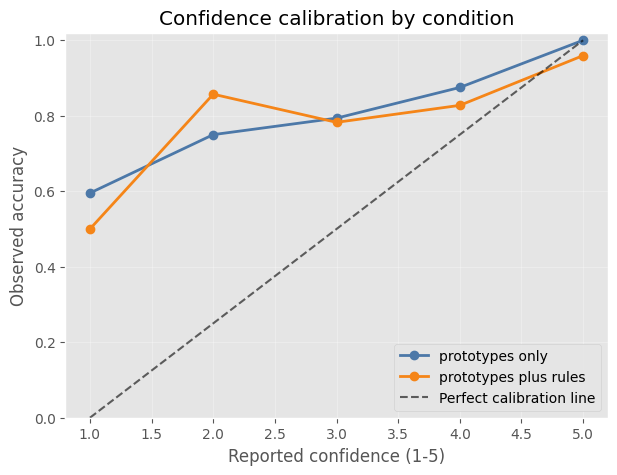

mean    std  count
condition             correct                    
prototypes_only       0.0      2.19  1.131     42
                      1.0      3.09  1.245    155
prototypes_plus_rules 0.0      3.37  1.043     27
                      1.0      4.03  1.014    169

In [ ]:
calibration = (
    item_df.dropna(subset=['confidence', 'correct'])
           .groupby(['condition', 'confidence'], as_index=False)
           .agg(empirical_accuracy=('correct', 'mean'), n=('correct', 'size'))
)

fig, ax = plt.subplots(figsize=(7, 5))
for condition, color in [('prototypes_only', '#4C78A8'), ('prototypes_plus_rules', '#F58518')]:
    subset = calibration[calibration['condition'] == condition]
    ax.plot(subset['confidence'], subset['empirical_accuracy'], marker='o', linewidth=2, color=color, label=condition.replace('_', ' '))
ax.plot([1, 5], [0, 1], '--', color='black', alpha=0.6, label='Perfect calibration line')
ax.set_xlabel('Reported confidence (1-5)')
ax.set_ylabel('Observed accuracy')
ax.set_title('Confidence calibration by condition')
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

item_df.groupby(['condition', 'correct'])['confidence'].agg(['mean', 'std', 'count']).round(3)


## Post-Task Likert Ratings

`rating_too_vague` and `rating_too_much_detail` are reverse-coded so that higher values consistently mean a more favorable explanation experience.


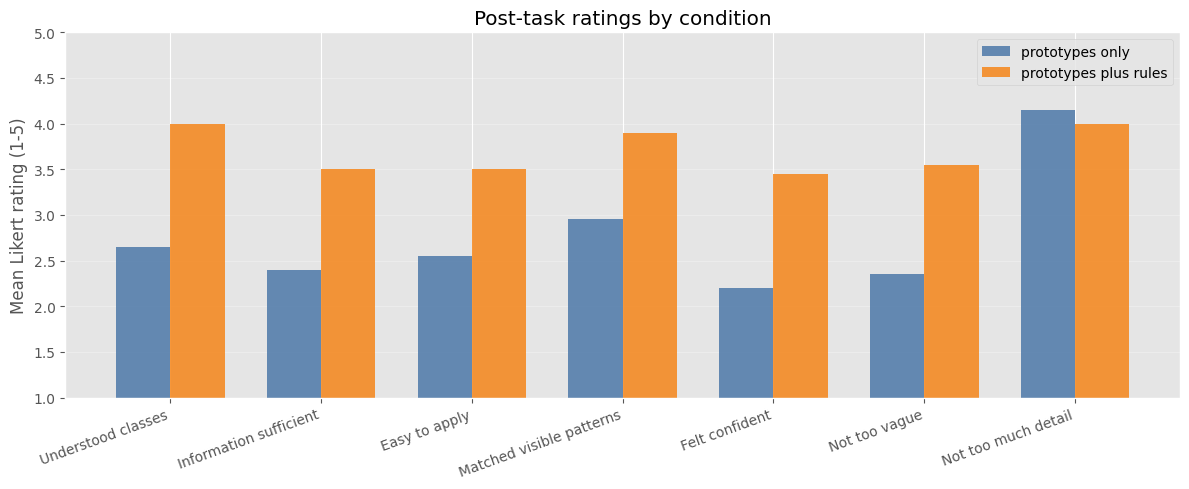

mean    std  count
item                     condition                                
confident                prototypes_only        2.20  1.196     20
                         prototypes_plus_rules  3.45  1.050     20
easy_to_apply            prototypes_only        2.55  0.999     20
                         prototypes_plus_rules  3.50  0.946     20
information_sufficient   prototypes_only        2.40  0.995     20
                         prototypes_plus_rules  3.50  1.051     20
matched_visible_patterns prototypes_only        2.95  0.999     20
                         prototypes_plus_rules  3.90  0.553     20
too_much_detail_rev      prototypes_only        4.15  0.745     20
                         prototypes_plus_rules  4.00  0.795     20
too_vague_rev            prototypes_only        2.35  0.875     20
                         prototypes_plus_rules  3.55  0.759     20
understood_classes       prototypes_only        2.65  1.089     20
                         prototypes_plus_rules  4.00  0.795     20

In [ ]:
likert_long = task_ratings.melt(
    id_vars=['participant_id', 'group', 'task_number', 'dataset', 'condition'],
    value_vars=[
        'rating_understood_classes',
        'rating_information_sufficient',
        'rating_easy_to_apply',
        'rating_matched_visible_patterns',
        'rating_confident',
        'too_vague_rev',
        'too_much_detail_rev',
    ],
    var_name='item',
    value_name='value',
)

likert_long['item'] = likert_long['item'].replace({
    'rating_understood_classes': 'understood_classes',
    'rating_information_sufficient': 'information_sufficient',
    'rating_easy_to_apply': 'easy_to_apply',
    'rating_matched_visible_patterns': 'matched_visible_patterns',
    'rating_confident': 'confident',
})

likert_barplot(likert_long, 'Post-task ratings by condition')
plt.show()

likert_long.groupby(['item', 'condition'])['value'].agg(['mean', 'std', 'count']).round(3)


## Participant Background and Task Outcomes

The interview CSV contains three numeric background measures:
- ML familiarity
- time-series plot familiarity
- XAI/rules familiarity

This section merges those with participant-level task summaries.


In [ ]:
interview_df = interview_raw.copy()
interview_df.columns = [str(c).replace('\ufeff', '').strip() for c in interview_df.columns]
for col in ['participant_id', 'group']:
    interview_df[col] = interview_df[col].astype('string').str.strip()
for col in ['ml_familiarity', 'ts_plot_familiarity', 'xai_rules_familiarity']:
    interview_df[col] = pd.to_numeric(interview_df[col], errors='coerce')

question_map = {
    '1': 'q1_visual_features_used',
    '2': 'q2_rules_helped',
    '3': 'q3_rules_confusing',
    '4': 'q4_reliance',
    '5': 'q5_preference',
    '6': 'q6_understanding_vs_task',
}
interview_df = interview_df.rename(columns=question_map)

participant_summary = (
    task_summary.groupby(['participant_id', 'group'], as_index=False)
                .agg(
                    mean_accuracy=('accuracy', 'mean'),
                    mean_confidence=('mean_confidence', 'mean'),
                    mean_quality=('explanation_quality_composite', 'mean'),
                    task1_accuracy=('accuracy', lambda s: s.iloc[0]),
                    task2_accuracy=('accuracy', lambda s: s.iloc[1] if len(s) > 1 else np.nan),
                )
)
participant_summary = participant_summary.merge(
    interview_df[['participant_id', 'group', 'ml_familiarity', 'ts_plot_familiarity', 'xai_rules_familiarity']],
    on=['participant_id', 'group'],
    how='left',
)

display(participant_summary)
participant_summary.corr(numeric_only=True).round(3)


,participant_id,group,mean_accuracy,mean_confidence,mean_quality,task1_accuracy,task2_accuracy,ml_familiarity,ts_plot_familiarity,xai_rules_familiarity
0,P01,A,0.750000,3.950000,3.857143,0.700000,0.800,2,3,2
1,P02,A,0.900000,4.050000,3.142857,0.900000,0.900,3,2,1
2,P03,A,0.900000,3.500000,3.142857,1.000000,0.800,2,5,1
3,P04,A,0.612500,2.798611,3.428571,0.600000,0.625,4,2,4
4,P05,A,0.788889,3.966667,3.642857,0.777778,0.800,4,4,3
5,P06,B,0.900000,4.244444,3.357143,0.900000,0.900,1,4,1
6,P07,B,0.800000,2.600000,3.000000,0.900000,0.700,5,5,5
7,P08,B,0.900000,2.450000,2.928571,1.000000,0.800,3,4,2
8,P09,B,0.700000,2.100000,2.357143,0.900000,0.500,2,1,2
9,P10,B,0.800000,3.200000,3.571429,0.800000,0.800,2,5,1


,mean_accuracy,mean_confidence,mean_quality,task1_accuracy,task2_accuracy,ml_familiarity,ts_plot_familiarity,xai_rules_familiarity
mean_accuracy,1.000,0.276,0.358,0.713,0.822,0.087,0.506,0.087
mean_confidence,0.276,1.000,0.391,-0.039,0.419,0.052,0.005,-0.021
mean_quality,0.358,0.391,1.000,0.040,0.469,-0.055,0.269,0.159
task1_accuracy,0.713,-0.039,0.040,1.000,0.187,0.029,0.472,-0.011
task2_accuracy,0.822,0.419,0.469,0.187,1.000,0.098,0.326,0.130
ml_familiarity,0.087,0.052,-0.055,0.029,0.098,1.000,0.191,0.873
ts_plot_familiarity,0.506,0.005,0.269,0.472,0.326,0.191,1.000,0.144
xai_rules_familiarity,0.087,-0.021,0.159,-0.011,0.130,0.873,0.144,1.000


## Interview Response Coverage

Before coding the open-ended responses, check how complete the final interview fields are.


In [ ]:
interview_questions = list(question_map.values())
coverage = pd.DataFrame({
    'question': interview_questions,
    'n_non_empty': [interview_df[q].notna().sum() for q in interview_questions],
    'n_missing': [interview_df[q].isna().sum() for q in interview_questions],
})
coverage


,question,n_non_empty,n_missing
0,q1_visual_features_used,17,3
1,q2_rules_helped,17,3
2,q3_rules_confusing,17,3
3,q4_reliance,17,3
4,q5_preference,17,3
5,q6_understanding_vs_task,16,4


## Lightweight Qualitative Coding

This is not a substitute for manual coding. It is a reproducible first pass that:
- extracts obvious preferences like `both` / `rules` / `prototypes`
- identifies repeated feature words such as `trend`, `peak`, `valley`, `plateau`
- flags whether participants explicitly said rules helped or were confusing

Use these outputs as a starting point for a manual qualitative pass, not as a final interpretation.


In [ ]:
def normalize_text(x):
    if pd.isna(x):
        return ''
    return re.sub(r'\s+', ' ', str(x).strip().lower())


def contains_any(text, patterns):
    return any(re.search(pattern, text) for pattern in patterns)


feature_theme_patterns = {
    'trend_or_slope': [r'\btrend\b', r'\brise\b', r'\bfall\b', r'go(es)? up', r'go(es)? down', r'\bincrease\b', r'\bdecrease\b'],
    'peak_or_trough': [r'\bpeak\b', r'\bpeaks\b', r'\btrough\b', r'\bvalley\b', r'\bspike\b'],
    'flat_or_plateau': [r'\bflat\b', r'\bplateau\b', r'\bbaseline\b'],
    'amplitude_or_height': [r'\bhigh\b', r'\blow\b', r'\bheight\b', r'\bamplitude\b', r'\blevel\b'],
    'timing_or_region': [r'\bearly\b', r'\bmiddle\b', r'\blate\b', r'\bbegin\b', r'\bend\b'],
}

help_patterns = {
    'helped_yes': [r'\byes\b', r'\bhelp', r'\buseful\b'],
    'helped_no': [r'\bno\b', r'did not help', r'not helpful'],
}

confusion_patterns = {
    'vague_or_unsure': [r'\bvague\b', r'confus', r'hard to', r'not sure'],
    'too_general': [r'often', r'tends', r'general', r'overfit'],
    'visual_mismatch': [r"couldn't see", r'hard to see', r'not visible', r"didn't match"],
}


def extract_preference(text):
    text = normalize_text(text)
    if not text:
        return pd.NA
    if 'both' in text:
        return 'both'
    if 'prototype' in text and 'rule' in text:
        return 'both'
    if 'prototype' in text:
        return 'prototypes_only'
    if re.search(r'\brules?\b', text):
        return 'rules_only'
    return 'other'


qual_rows = []
for _, row in interview_df.iterrows():
    q1 = normalize_text(row['q1_visual_features_used'])
    q2 = normalize_text(row['q2_rules_helped'])
    q3 = normalize_text(row['q3_rules_confusing'])
    q4 = normalize_text(row['q4_reliance'])
    q5 = normalize_text(row['q5_preference'])
    feature_hits = [name for name, pats in feature_theme_patterns.items() if contains_any(q1, pats)]
    help_hits = [name for name, pats in help_patterns.items() if contains_any(q2, pats)]
    confusion_hits = [name for name, pats in confusion_patterns.items() if contains_any(q3, pats)]
    qual_rows.append({
        'participant_id': row['participant_id'],
        'group': row['group'],
        'feature_themes': ', '.join(feature_hits) if feature_hits else pd.NA,
        'rules_help_signal': ', '.join(help_hits) if help_hits else pd.NA,
        'confusion_signal': ', '.join(confusion_hits) if confusion_hits else pd.NA,
        'reliance_normalized': extract_preference(q4),
        'preference_normalized': extract_preference(q5),
        'understanding_text': row['q6_understanding_vs_task'],
    })

qual_df = pd.DataFrame(qual_rows)
display(qual_df)


,participant_id,group,feature_themes,rules_help_signal,confusion_signal,reliance_normalized,preference_normalized,understanding_text
0,P01,A,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,P02,A,trend_or_slope,helped_yes,"vague_or_unsure, too_general",rules_only,both,It helps me to understand the classifier better.
2,P03,A,<NA>,<NA>,<NA>,rules_only,both,rules made me understand the classification better.
3,P04,A,timing_or_region,helped_yes,<NA>,rules_only,both,"Yes, helped me understand the classifier better"
4,P05,A,<NA>,<NA>,<NA>,rules_only,both,I could see how rules could improve my ability to classify
5,P06,B,<NA>,helped_yes,<NA>,both,both,I do think it helped me to iunderstand the difference.
6,P07,B,<NA>,<NA>,<NA>,rules_only,both,Both
7,P08,B,"trend_or_slope, amplitude_or_height",helped_yes,<NA>,both,rules_only,<NA>
8,P09,B,"peak_or_trough, timing_or_region",helped_yes,vague_or_unsure,both,both,Mainly help with ensuring the test
9,P10,B,<NA>,helped_yes,<NA>,rules_only,both,Mainlt answer the test


In [ ]:
def explode_counter(series):
    counter = Counter()
    for value in series.dropna():
        for token in [x.strip() for x in str(value).split(',') if x.strip()]:
            counter[token] += 1
    return pd.DataFrame(counter.items(), columns=['theme', 'count']).sort_values(['count', 'theme'], ascending=[False, True])

print('Feature themes')
display(explode_counter(qual_df['feature_themes']))
print('Rules-help signals')
display(explode_counter(qual_df['rules_help_signal']))
print('Confusion signals')
display(explode_counter(qual_df['confusion_signal']))
print('Preference summary')
display(qual_df['preference_normalized'].value_counts(dropna=False).rename_axis('preference').reset_index(name='count'))
print('Reliance summary')
display(qual_df['reliance_normalized'].value_counts(dropna=False).rename_axis('reliance').reset_index(name='count'))


Feature themes


,theme,count
1,timing_or_region,5
0,trend_or_slope,3
2,amplitude_or_height,2
3,peak_or_trough,1


Rules-help signals


,theme,count
0,helped_yes,11
1,helped_no,1


Confusion signals


,theme,count
0,vague_or_unsure,3
1,too_general,1


Preference summary


,preference,count
0,both,15
1,<NA>,3
2,rules_only,2


Reliance summary


,reliance,count
0,rules_only,10
1,both,4
2,<NA>,3
3,other,2
4,prototypes_only,1


In [ ]:
example_columns = [
    'participant_id',
    'q1_visual_features_used',
    'q2_rules_helped',
    'q3_rules_confusing',
    'q4_reliance',
    'q5_preference',
    'q6_understanding_vs_task',
]
interview_df[example_columns]


,participant_id,q1_visual_features_used,q2_rules_helped,q3_rules_confusing,q4_reliance,q5_preference,q6_understanding_vs_task
0,P01,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,P02,The trend of the curve,"Yes, it helps a bit the rules about where the curves goes up and down.","I guess the rules are made to avoid overfitting. So there are phrases such as 'ofren', 'tends' in the rules. But this may lead to confusion. Because there are sometimes both read and blue contained.",rules,both,It helps me to understand the classifier better.
2,P03,"In task 1 I mainly used the slope at the very start, in task 2 steepness of recovery and have gradual transition","I mainly focused on the slope, slow vs fast recovery",Any rule not quantified will have instances on the boarder e.g where is the cut off point between fast and clear.,I relied mainly on the examples. but rules told me where to focus,both,rules made me understand the classification better.
3,P04,"Task 1, even bumps, taks 3 drastic upwards steps declining/upwards at the end.","Yes, late region declines/goes up",No,Rules,Both,"Yes, helped me understand the classifier better"
4,P05,"Abrupt changes, steepness and jaggedness","The rules were crucial, part two felt way easier","As mentioned, one example could have been representative of the other class. Other than that, I felt confident in my ability to classify each class in part 2",Mostly rules,"Both preferably, but rules would be sufficient",I could see how rules could improve my ability to classify
5,P06,How much did the plot fluctuate and its differences.,"Yes, I find all rules to be useful. It helped me to better understand the difference","I do not think so, although having specific values is not of mush help",rules guided me to see the differences more clearly in the prototypes,Definitly both,I do think it helped me to iunderstand the difference.
6,P07,Rules,All,No,Rules,Both,Both
7,P08,"Dip, the ratical asant and how quick the assant is, how low you get before the rise.","Yes, with the slop of the first. Plot 1 vs plot 3 for samples.",Rules helped quite a lot,Both,Rules help with more plots without other samples. More specific rules should help more.,<NA>
8,P09,"For the first task, I applied the explanations of looking at the early region. The second task, no visual features I think. Maybe the largest peaks and where they appeared well as the shape of the...","Yes, in the first task, with specific rules helped. In assigning with class it belongs to.","Yes, the second task with no rules. It was hard to label.","I think I used rules, and if that seemed unclear I went back to prototypes",Both,Mainly help with ensuring the test
9,P10,Top and bottom points,"Yes. In the first task, I ifnored all other visual other than the rules. It made it clearer",Yes. second task was difficult to distinguish,rules in the condition,Both rules for logic and prototypes for intuition,Mainlt answer the test
